---

<h1><center>ENGIN178 Final Project<br><br> Group 14 </center></h1>

---
This project is designed to take blended body delta wing aircraft positional state given in yaw angle, pitch angle, as well as the absolute and relative degree of elevon and map that to aerodynamic force and moment coefficients to be used in a controller.

+ Load the data
+ Split the data into training, validation, and testing datasets
+ Normalize the data
+ Organize the data into input sequences and output values
+ Train these models
    + Linear regression
    + Multi-layer perceptron (a.k.a. dense neural network)
    + simple RNN
    + LSTM
+ Compare the models
+ Compute performance of the best model

In [2]:
#importing dependencies (Copied from HW4)
import os
import random
import numpy as np
import pandas as pd
from pandas.core.indexes.datetimes import DatetimeIndex
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
#from resources.hashutils import *
os.environ['PYTHONHASHSEED'] = '0'  # optional, for hash-based functions
#random.seed(2434)
#np.random.seed(2434)
#torch.manual_seed(2434)
#torch.use_deterministic_algorithms(True)
np.set_printoptions(precision=4)

def predict_model(model, x):
    model.eval()
    x_tensor = torch.tensor(np.asarray(x), dtype=torch.float32)
    with torch.no_grad():
        yhat = model(x_tensor).detach().cpu().numpy()
    return yhat

def predict_any(model, x):
    if isinstance(model, nn.Module):
        return predict_model(model, x)
    return model.predict(x)

**Step 0: Mixing the Rows of Our Data**

This step is necessary becasue the csv is data that was generated by VspAero is organized in the angle of attack sweeps meaning that if we were to split this base csv into training, validation, and test data we would be missing ebtire sweeps in the training. To remedy this the rows of the csv need to be randomly shuffled to ensure an even distribution of the different cfd sweeps.

This 

In [3]:
# if still need to shuffle data
unshuffledDat = pd.read_csv('aero_master.csv')
unshuffledDatNew =unshuffledDat.drop('source_file', axis=1)
shuffledDat = unshuffledDatNew .sample(frac=1, random_state = 31).reset_index(drop=True)
shuffledDat.to_csv('shuffledAeroMaster.csv', index=False)

In [4]:
# if the shuffle has alreday been done just run this 
shuffledDat = pd.read_csv('shuffledAeroMaster.csv')

In [11]:
# create the function that will split our data up into train, validate, and test lists. pt indicates percent train, pv 
# indicates percent validate... please use float

def splitData(pt,pv):

    assert(pt>=0)
    assert(pv>=0)
    assert(pt+pv<=1)

    N = shuffledDat.shape[0]

    train_end = int(N*pt)
    val_end = train_end + int(N*pv)

    data_train = shuffledDat.copy().iloc[:train_end]
    data_validate = shuffledDat.copy().iloc[train_end:val_end]
    data_test = shuffledDat.copy().iloc[val_end:]
    
    #data_train = raw_data.sample(n=int(N*pt))
    #data_validate = raw_data.drop(data_train.index).sample(n=int(N*pv))
    #data_test = raw_data.drop(data_train.index).drop(data_validate.index)
    
    return data_train, data_validate, data_test

In [12]:
#test the data
# test your code:
dataTrain, dataValidate, dataTest = splitData(0.70,0.10)


In [ ]:
# normalize and scale the data using StandardScaler() method from scikit learn
from sklearn.preprocessing import StandardScaler

xScaler = StandardScaler()
yScaler = StandardScaler()

xTrain = dataTrain[["alpha_deg","beta_deg","deltaS_deg","deltaD_deg"]]
yTrain = dataTrain[["CL","CD","CY","Cl","Cm","Cn"]]

xValidate = dataValidate[["alpha_deg","beta_deg","deltaS_deg","deltaD_deg"]]
yValidate = dataValidate[["CL","CD","CY","Cl","Cm","Cn"]]

xTest = dataTest[["alpha_deg","beta_deg","deltaS_deg","deltaD_deg"]]
yTest = dataTest[["CL","CD","CY","Cl","Cm","Cn"]]

xTrainScaled = xScaler.fit_transform(xTrain)
xTestScaled = xScaler.transform(xTrain)
xValidateScaled = xScaler.transform(xValidate)

yTrainScaled = yScaler.fit_transform(yTrain)
yTestScaled = yScaler.transform(yTrain)
yValidateScaled = yScaler.transform(yValidate)

Buidling a multi-logistic regression.

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 1. Initialize the Multi-Linear Regression model
modelLr = LinearRegression()

# 2. Train the model 
# We feed it the scaled inputs, and it will learn to map them to the unscaled targets
modelLr.fit(xTrainScaled, yTrain)

# 3. Predict on the validation set
validatePred = modelLr.predict(xValidateScaled)

# 4. Evaluate the model
individualMaes = mean_absolute_error(yValidate, validatePred, multioutput='raw_values')

parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]
print("Multi-Linear Regression Validation MAE by Parameter:")
for param, mae in zip(parameters, individualMaes):
    print(f"{param}: {mae:.5f}")

Multi-Linear Regression Validation MAE by Parameter:
CL: 0.00426
CD: 0.01749
CY: 0.00147
Cl: 0.00410
Cm: 0.00785
Cn: 0.00119


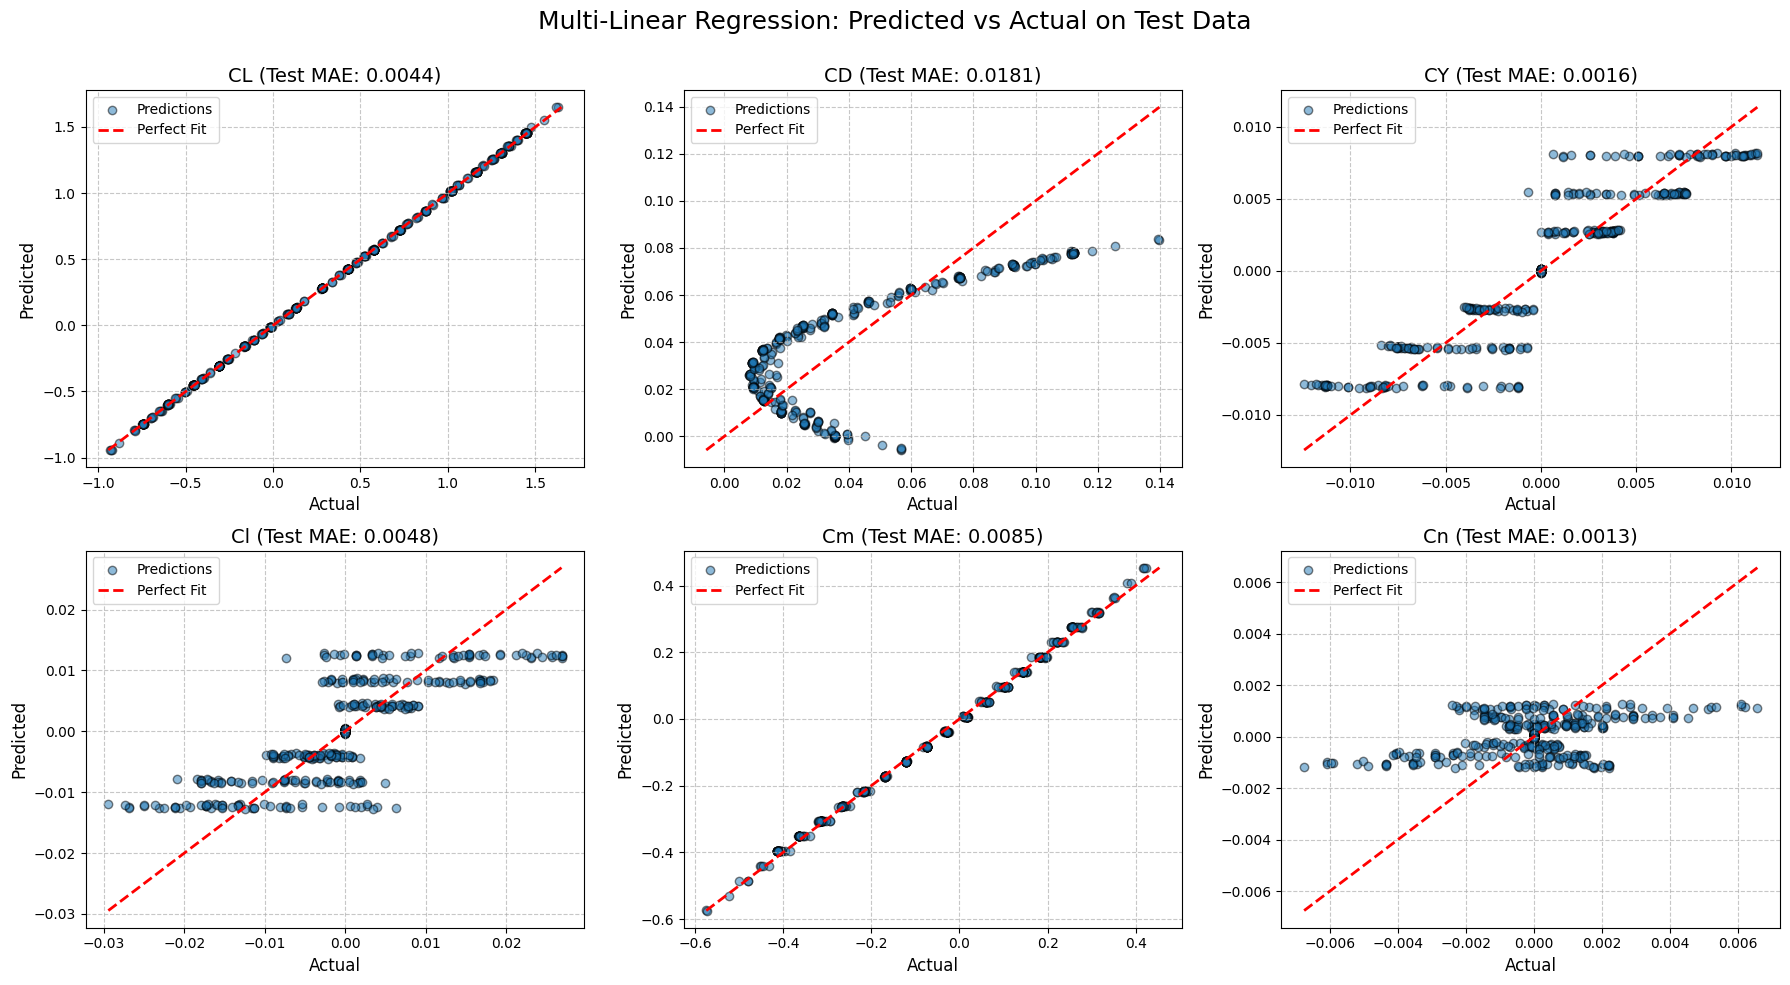

In [35]:

# 1. Extract test features and targets from your existing dataTest subset
xTest = dataTest[["alpha_deg", "beta_deg", "deltaS_deg", "deltaD_deg"]]
yTest = dataTest[["CL", "CD", "CY", "Cl", "Cm", "Cn"]]

# 2. Scale the test features using the xScaler you fit on your training data
# (Ensure xScaler = StandardScaler() and xScaler.fit(xTrain) were run previously)
xTestScaled = xScaler.transform(xTest)

# 3. Predict using your already-trained multi-linear regression model
testPred = modelLr.predict(xTestScaled)

# 4. Calculate MAE specifically for the TEST data to use in the plot titles
testMaes = mean_absolute_error(yTest, testPred, multioutput='raw_values')
parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]

# 5. Generate the Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Multi-Linear Regression: Predicted vs Actual on Test Data', fontsize=18)

axes = axes.flatten()

for i, target in enumerate(parameters):
    ax = axes[i]
    actual = yTest[target].values
    predicted = testPred[:, i]
    
    # Scatter plot of Actual vs Predicted
    ax.scatter(actual, predicted, alpha=0.5, edgecolor='k', label='Predictions')
    
    # Plot the ideal 'Perfect Prediction' 1:1 line
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    
    ax.set_title(f"{target} (Test MAE: {testMaes[i]:.4f})", fontsize=14)
    ax.set_xlabel('Actual', fontsize=12)
    ax.set_ylabel('Predicted', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

Bulding and training a simple RNN in PyTorch

In [19]:
#data preparation: this code block converts our data pools into respective pytorch tensors
#specifically for this RNN we have to reshape our inputs to fit with the RNN architecture

# reshaping from (N, 4) to (N, 1, 4)
xTrainSeq = torch.tensor(xTrainScaled, dtype=torch.float32).reshape(-1, 1, 4)
xValidateSeq = torch.tensor(xValidateScaled, dtype=torch.float32).reshape(-1, 1, 4)
xTestSeq = torch.tensor(xTestScaled, dtype=torch.float32).reshape(-1, 1, 4)

# Convert y to Tensors (keeps 2D shape: batch_size, 6 outputs)
yTrainT = torch.tensor(yTrainScaled, dtype=torch.float32)
yValidateT = torch.tensor(yValidateScaled, dtype=torch.float32)
yTestT = torch.tensor(yTestScaled, dtype=torch.float32)

# Create DataLoader
trainLoaderSeq = DataLoader(
    TensorDataset(xTrainSeq, yTrainT),
    batch_size=32,
    shuffle=True
)

In [20]:
# now that our data is sorted we can create the SimpleRNN, it feeds through then extracts the data into a linear layer
# for all 6 of our aero parameters

class AeroSimpleRNN(nn.Module):
    def __init__(self):
        super(AeroSimpleRNN, self).__init__()
        # input_size=4 (alpha, beta, deltaS, deltaD)
        # hidden_size=32 (number of neurons in the hidden state)
        self.rnn = nn.RNN(input_size=4, hidden_size=32, num_layers=2, batch_first=True)
        
        # Output layer maps the hidden state to the 6 target aero parameters
        self.output = nn.Linear(32, 6)

    def forward(self, x):
        # x shape: (batch_size, sequence_length=1, input_size=4)
        out, h_n = self.rnn(x)
        
        # out shape: (batch_size, seq_length=1, hidden_size=32)
        # We grab the output of the final time step (which is index 0 since length is 1)
        finalTimestepOut = out[:, -1, :] 
        
        # Map to 6 aerodynamic coefficients
        predictions = self.output(finalTimestepOut)
        return predictions

# Instantiate
modelSrnn = AeroSimpleRNN()

In [ ]:
import torch.optim as optim
from sklearn.metrics import mean_absolute_error
import torch.nn as nn

optimizerSrnn = optim.Adam(modelSrnn.parameters(), lr=0.001)
lossFnSrnn = nn.MSELoss()
historySrnn = {"epoch": [], "mae": [], "valMae": []}

epochs = 100

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    modelSrnn.train()
    for xb, yb in trainLoaderSeq:
        optimizerSrnn.zero_grad()
        pred = modelSrnn(xb)
        loss = lossFnSrnn(pred, yb)
        loss.backward()
        optimizerSrnn.step()

    # --- EVALUATION PHASE ---
    modelSrnn.eval()
    with torch.no_grad():
        # Get predictions using the camelCase input tensors
        trainPredScaled = modelSrnn(xTrainSeq).cpu().numpy()
        validatePredScaled = modelSrnn(xValidateSeq).cpu().numpy()

    # Un-scale the predictions back to real aero coefficients using your yScaler
    trainPred = yScaler.inverse_transform(trainPredScaled)
    validatePred = yScaler.inverse_transform(validatePredScaled)

    historySrnn["epoch"].append(epoch)
    
    # Calculate MAE using your original un-scaled dataframes (yTrain, yValidate)
    historySrnn["mae"].append(mean_absolute_error(yTrain, trainPred))
    historySrnn["valMae"].append(mean_absolute_error(yValidate, validatePred))
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train MAE: {historySrnn['mae'][-1]:.5f} | Val MAE: {historySrnn['valMae'][-1]:.5f}")

print(f"Final Validation MAE: {historySrnn['valMae'][-1]:.5f}")

Epoch 010/50 | Train MAE: 0.00056 | Val MAE: 0.00052
Epoch 020/50 | Train MAE: 0.00040 | Val MAE: 0.00036
Epoch 030/50 | Train MAE: 0.00072 | Val MAE: 0.00068
Epoch 040/50 | Train MAE: 0.00044 | Val MAE: 0.00041
Epoch 050/50 | Train MAE: 0.00041 | Val MAE: 0.00040
Final Validation MAE: 0.00040


In [31]:
from sklearn.metrics import mean_absolute_error

# Get final predictions
modelSrnn.eval()
with torch.no_grad():
    validatePredScaled = modelSrnn(xValidateSeq).cpu().numpy()

# Unscale back to real aero coefficients
validatePred = yScaler.inverse_transform(validatePredScaled)

# Calculate MAE for EACH column using multioutput='raw_values'
individual_maes = mean_absolute_error(yValidate, validatePred, multioutput='raw_values')

# Print them out clearly
parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]
print("Validation MAE by Parameter:")
for param, mae in zip(parameters, individual_maes):
    print(f"{param}: {mae:.5f}")

Validation MAE by Parameter:
CL: 0.00156
CD: 0.00014
CY: 0.00004
Cl: 0.00005
Cm: 0.00059
Cn: 0.00001


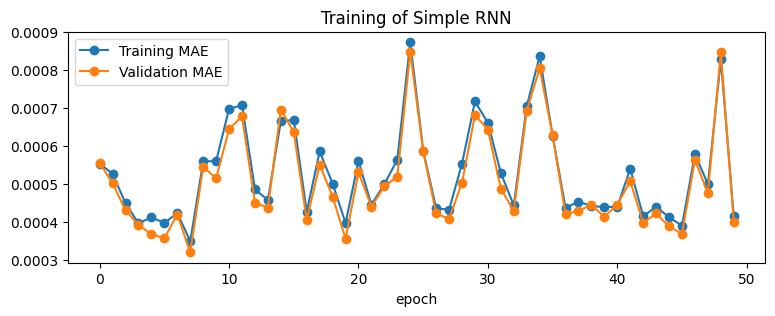

In [32]:
#plotting the training history of the SimpleRNN

numEpochs = len(historySrnn['epoch'])
plt.figure(figsize=(9,3))
plt.plot(range(numEpochs), historySrnn['mae'], marker='o', label='Training MAE')
plt.plot(range(numEpochs), historySrnn['valMae'], marker='o', label='Validation MAE')
plt.xlabel('epoch')
plt.title('Training of Simple RNN')
plt.legend();